## Notebook 9
Build an ML model that predicts lap time degradation (or lap time) based on tyre and race conditions.

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [45]:
# Load dataset
data = pd.read_csv("../data/processed/master_dataset.csv")

# Load driver profiles
driver_profiles = pd.read_csv("../notebooks/driver_profiles_with_clusters.csv")

driver_profiles = driver_profiles[
    ["Driver", "DrivingStyleCluster", "DrivingStyle"]
]

# Merge FIRST
data = data.merge(
    driver_profiles,
    on="Driver",
    how="left"
)

# THEN create features
features = [
    "TyreLife",
    "Compound",
    "Driver",
    "Team",
    "Stint",
    "TrackStatus",
    "Position",
    "DrivingStyleCluster"
]

X = pd.get_dummies(data[features], drop_first=True)

In [75]:
driver_profiles = driver_profiles[
    ["Driver", "DrivingStyleCluster", "DrivingStyle"]
]

df = df.merge(
    driver_profiles[["Driver", "DrivingStyleCluster"]],
    on="Driver",
    how="left"
)

In [57]:
data[["Driver", "DrivingStyleCluster"]].head()

,Driver,DrivingStyleCluster
0,VER,2.0
1,VER,2.0
2,VER,2.0
3,VER,2.0
4,VER,2.0


In [56]:
# select features

features = [
    "TyreLife",
    "Stint",
    "TrackStatus",
    "Position",
    "Compound",
    "Driver",
    "Team",
    "DrivingStyleCluster"
]

target = "LapTimeSeconds"

data = df[features + [target]].copy()

In [6]:
# handling the missing values

data.isnull().sum()

TyreLife          0
Compound          0
Driver            0
Team              0
Stint             0
TrackStatus       0
Position          0
LapTimeSeconds    0
dtype: int64

In [58]:
# convert categorical features into numeric values

data = pd.get_dummies(
    data,
    columns=["Compound", "Driver", "Team"],
    drop_first=True
)

In [59]:
target = "LapTimeSeconds"

features = [col for col in data.columns if col != target]

In [66]:
# train and test split

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:

data = data.dropna(subset=["DrivingStyleCluster"]).reset_index(drop=True)


In [69]:
# training different regression models

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("All models trained successfully!")

All models trained successfully!


In [71]:
# evaluating the model

results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
1,Random Forest,3.421670,5.770263,0.621399
2,XGBoost,5.655932,6.722342,0.486156
0,Linear Regression,7.961036,9.249105,0.027276


In [72]:
# selecting the best model

best_model_name = results_df.sort_values(
    "R2 Score",
    ascending=False
).iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


,Feature,Importance
0,TyreLife,0.257870
3,Position,0.245036
1,Stint,0.075833
6,Compound_SOFT,0.045543
5,Compound_MEDIUM,0.039665
4,DrivingStyleCluster,0.026271
42,Team_Williams,0.015941
38,Team_McLaren,0.014178
33,Team_Alpine,0.013277
17,Driver_MAG,0.013234


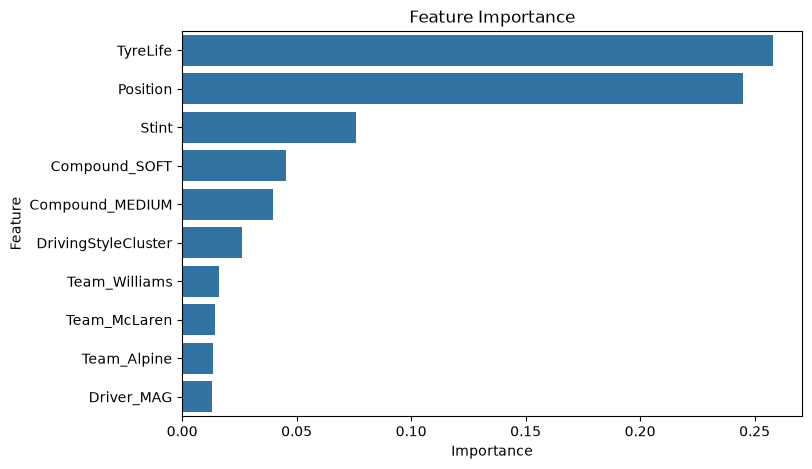

In [73]:
# feature importance

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": features,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
    "Importance",
    ascending=False
).head(10)

    display(importance)

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title("Feature Importance")
    plt.show()

else:
    print("Feature importance not available for this model.")

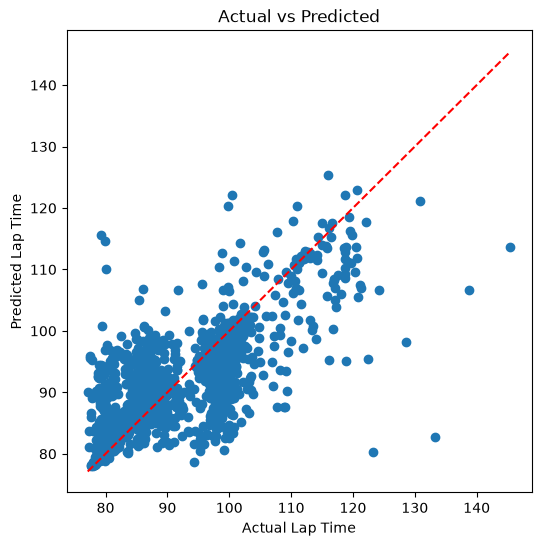

In [74]:
# actual vs predicted

predictions = best_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Lap Time")
plt.ylabel("Predicted Lap Time")
plt.title("Actual vs Predicted")

plt.show()